In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import copy
from tqdm import tqdm
from pathlib import Path
import networkx as nx

from src.load_data import (
    read_graph_transport_networks_tntp,
    read_traffic_mat_transport_networks_tntp,
)

from src.models import BeckmannModel, TwostageModel
from src.algs import cyclic, ustm, frank_wolfe, N_conjugate_frank_wolfe
from src.salim import SaddleOracle, combined_salim
from src.saddle_ta import salim_ta, chambolle_pock_ta
from src.approx import seq_quad

import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator


plt.rcParams.update({'font.size': 14})
%config InlineBackend.figure_format = 'retina'

%matplotlib inline

# Load network data

In [3]:
networks_path = Path("./TransportationNetworks")

# folder = "SiouxFalls"
# net_name = "SiouxFalls_net"
# traffic_mat_name = "SiouxFalls_trips"

folder = "Anaheim"
net_name = "Anaheim_net"
traffic_mat_name = "Anaheim_trips"

# folder = "Barcelona"
# net_name = "Barcelona_net"
# traffic_mat_name = "Barcelona_trips"

# folder = "Austin"
# net_name = "Austin_net"
# traffic_mat_name = "Austin_trips_am"

# folder = "Berlin-Friedrichshain"
# net_name = "friedrichshain-center_net"
# traffic_mat_name = "friedrichshain-center_trips"

# folder = "Terrassa-Asymmetric"
# net_name = "Terrassa-Asym_net"
# traffic_mat_name = "Terrassa-Asym_trips"

net_file = networks_path / folder / f"{net_name}.tntp"
traffic_mat_file = networks_path / folder / f"{traffic_mat_name}.tntp"
graph, metadata = read_graph_transport_networks_tntp(net_file)
correspondences = read_traffic_mat_transport_networks_tntp(traffic_mat_file, metadata)
n = graph.number_of_nodes()

print(f"{graph.number_of_edges()=}, {graph.number_of_nodes()=}")

metadata["can_pass_through_zones"]=False
graph.number_of_edges()=914, graph.number_of_nodes()=454


In [4]:
traffic_mat = correspondences.traffic_mat.copy()
departures, arrivals = traffic_mat.sum(axis=1), traffic_mat.sum(axis=0)
l, w = departures, arrivals

# Create instances of models/oracles

In [5]:
mu_bm=None
beckmann_model = BeckmannModel(graph, copy.deepcopy(correspondences),mu_bm)
# twostage_beckmann_model = TwostageModel(beckmann_model, departures=departures, arrivals=arrivals, gamma=0.1)
# saddle_oracle = SaddleOracle(twostage_beckmann_model.traffic_model, twostage_beckmann_model.gamma, l, w)

eps = 1e-6
mean_bw = beckmann_model.graph.ep.capacities.a.mean()
mean_cost = beckmann_model.graph.ep.free_flow_times.a.mean()

# cost suboptimality <= eps * (average link cost * avg bandwidth * |E| \approx total cost when beta=1)
eps_abs = eps * mean_cost * mean_bw * graph.number_of_edges()

eps_cons_abs = eps * mean_bw
# sum of capacity violation <= eps * average link capacity
print(eps_abs, eps_cons_abs)

4.86317887193558 0.006030196936542669


In [12]:
mus = np.array(list(nx.get_edge_attributes(graph, "mu").values()), dtype=np.float32)
mus_inv = np.round(1 / mus).astype(np.int32)


In [35]:
beckmann_model.solve_cvxpy(solver="CLARABEL")

TypeError: unsupported operand type(s) for ** or pow(): 'numpy.int64', 'int', 'int'

In [20]:
incidence_mat.shape, flows_ei.shape, traffic_lapl.shape

((454, 914), (914, 38), (454, 38))

In [33]:
import cvxpy as cp
traffic_lapl = SaddleOracle(beckmann_model, None, None, None).Bmul(beckmann_model.correspondences.traffic_mat).T

incidence_mat = nx.incidence_matrix(graph, oriented=True).todense()

capacities = np.array(list(nx.get_edge_attributes(graph, "capacities").values()), dtype=np.float32)
ffts = np.array(
    list(nx.get_edge_attributes(graph, "free_flow_times").values()),
    dtype=np.float32,
)
rhos = np.array(list(nx.get_edge_attributes(graph, "rho").values()), dtype=np.float32)
mus = np.array(list(nx.get_edge_attributes(graph, "mu").values()), dtype=np.float32)
mus_inv = np.round(1 / mus).astype(int)

assert np.allclose(mus_inv, 1 / mus), "now only works for integer 1/mu s"


flows_ei = cp.Variable((len(graph.edges), traffic_lapl.shape[1]), nonneg=True)
flows_e = cp.sum(flows_ei, axis=1)
# flows_e = cp.Variable(len(graph.edges), nonneg=True)

# in cvxpy, power should be scalar, so use loop
sigmas = [
    ffts[e]
    * (
        flows_e[e]
        + (rhos[e] / (1.0 + mus_inv[e])) * (cp.pos(flows_e[e] * 1.0) ** (1 + mus_inv[e]) / (capacities[e] * 1.0) ** (mus_inv[e]))
    )
    for e in range(len(graph.edges))
]
objective = cp.Minimize(cp.sum(sigmas))
# objective = cp.Minimize(0)

prob = cp.Problem(
    objective,
    [
        (incidence_mat @ flows_ei) == -traffic_lapl,
    ],
)
prob.solve(solver="CLARABEL")
flows_ei = flows_ei.value if flows_ei is not None else None
potentials = [cons.dual_value for cons in prob.constraints]
flows_ei, potentials



TypeError: unsupported operand type(s) for ** or pow(): 'numpy.int64', 'int', 'int'

In [13]:
A = incidence_mat = nx.incidence_matrix(beckmann_model.nx_graph, oriented=True).todense()

svals = np.linalg.svd(A)[1]
lam1 = svals[0]
lam2 = svals[svals > 1e-8][-1]
print(lam1, lam2)


3.928244237354051 0.16274761956611847


# Obtain almost exact solution

In [14]:
A = incidence_mat = nx.incidence_matrix(beckmann_model.nx_graph, oriented=True).todense()

saddle_oracle = SaddleOracle(beckmann_model, None, None, None)

Ld = saddle_oracle.Bmul(beckmann_model.correspondences.traffic_mat).T
b = -Ld

svals = np.linalg.svd(A)[1]
lam1 = svals[0] ** 2
lam2 = svals[svals > 1e-8][-1] ** 2

L_sq = lam1 + Ld.shape[0]

lam1 *= 2
lam2 /= 2
lam1, lam2

mu = 2e-3
L = 100
iters = 2000000

_, flows_true, _, _ = N_conjugate_frank_wolfe(
    beckmann_model, eps_abs, max_iter=8000, stop_by_crit=True, cnt_conjugates=3, linesearch=True, log_max_diff=False, log_period=0)

100%|██████████| 7999/7999 [01:57<00:00, 67.84it/s]


In [15]:
np.save(f"experiments_data/true_flows_{folder}.npy", flows_true)
# flows_true = np.load(f"experiments_data/true_flows_{folder}.npy")

# Run OFAC

In [18]:
data = {"fw": {}, "nfw": {}, "chp" : {}, "seq_quad": {}}
saddle_methods = ["apdhg", "chp"]
log_max_diff=False

In [ ]:
model_name = "fw"
max_iter=8000
data[model_name]["times"], data[model_name]["flows"], logs, _ = frank_wolfe(beckmann_model, eps_abs, max_iter=max_iter, stop_by_crit=False, linesearch=True, log_max_diff=log_max_diff, log_period=max_iter//400, solution_flows=flows_true)
data[model_name]["dgap"], data[model_name]["time_log"], data[model_name]["primal"], data[model_name]["r_gap"], data[model_name]["flows_diff"] = logs

In [27]:
model_name = "nfw"
max_iter = 1000
data[model_name]["times"], data[model_name]["flows"], logs, _  = N_conjugate_frank_wolfe(
    beckmann_model, eps_abs, max_iter=max_iter, stop_by_crit=False, cnt_conjugates=3, linesearch=True, log_max_diff=log_max_diff, log_period=max_iter//400, solution_flows=flows_true
)
data[model_name]["dgap"], data[model_name]["time_log"], data[model_name]["primal"], data[model_name]["r_gap"], data[model_name]["flows_diff"] = logs

100%|██████████| 999/999 [00:14<00:00, 68.89it/s]


In [29]:
iters = 1900
restart = 30

model_name = "chp"
data[model_name] = {}
data[model_name]["flows"], data[model_name]["flows_diff_delta"], data[model_name]["cons"], \
    data[model_name]["opt_log"], data[model_name]["time_log"], \
    data[model_name]["primal"], _, data[model_name]["flows_diff"] = \
    chambolle_pock_ta(beckmann_model, iters=iters, log_max_diff=log_max_diff, log_period=iters//400, solution_flows=flows_true)

100%|██████████| 1900/1900 [00:35<00:00, 53.51it/s, nu=64, gamma=0.015, theta=1, sol dist=6.7e+3, primal=1.28e+6] 


In [24]:

seq_quad(beckmann_model, iters=1,solution_flows=np.zeros(beckmann_model.graph.num_edges()))

(454, 914) (454, 38)


  0%|          | 0/1 [00:06<?, ?it/s]


KeyboardInterrupt: 

In [19]:
iters = 10

model_name = "seq_quad"
data[model_name] = {}
data[model_name]["flows"], data[model_name]["cons"], data[model_name]["time_log"], \
    data[model_name]["primal"], data[model_name]["flows_diff"] = \
    seq_quad(beckmann_model, iters=iters, log_max_diff=log_max_diff, need_log=True, solution_flows=flows_true)

100%|██████████| 10/10 [01:19<00:00,  7.97s/it, sol dist=0.0921, primal=1.29e+6]


In [37]:
from src.shortest_paths_gt import (
    distance_mat_gt,
    flows_on_shortest_gt,
    get_graph_props,
    get_graphtool_graph,
)


In [44]:
beckmann_model.graph

<Graph object, directed, with 454 vertices and 914 edges, 5 internal edge properties, at 0x7f9e99aa4200>

In [45]:

beckmann_model.solve_cvxpy(solver="CLARABEL")

TypeError: argument should be a string or a Rational instance

# Save results

In [30]:
import json

In [31]:
import json
from pathlib import Path


dirname = folder + f"_mu={mu_bm}"
Path(f"experiments_data/{dirname}").mkdir(parents=True, exist_ok=True)
with open(f"experiments_data/{dirname}/{dirname}.json", "w+") as fp:
    json.dump(data, fp, indent=4)
    

# Plot results

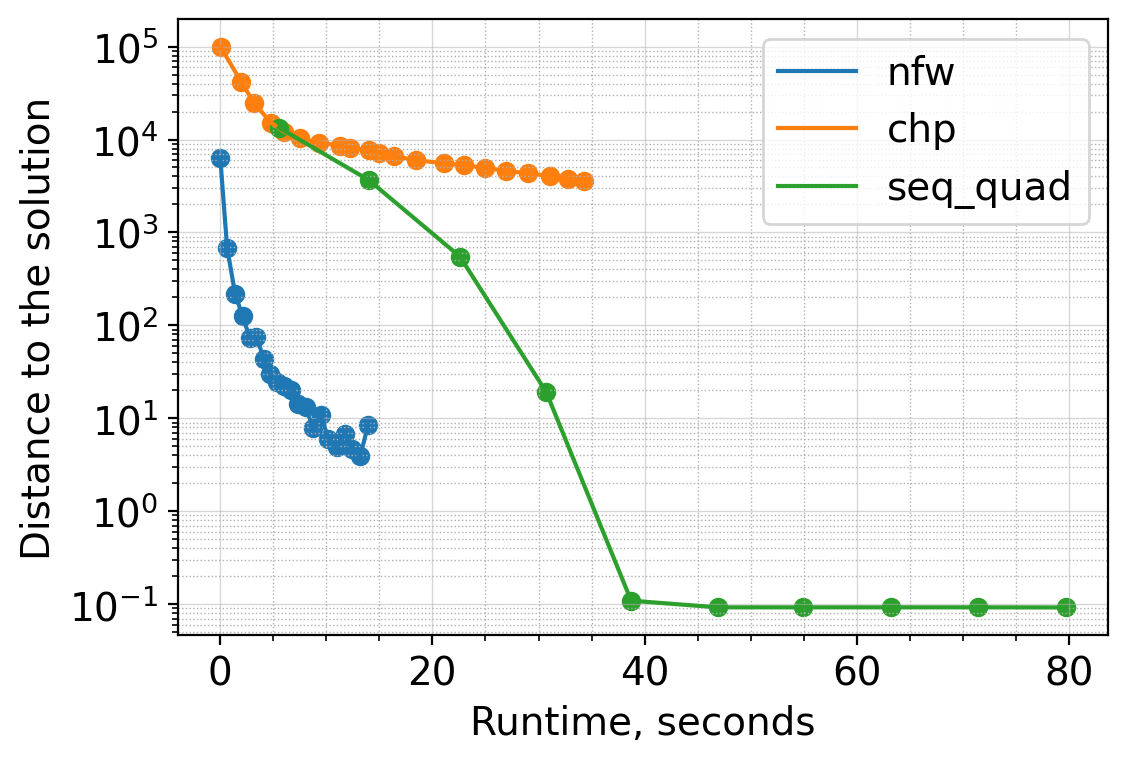

In [34]:
with open(f"experiments_data/{dirname}/{dirname}.json", "r") as fp:
    data: dict = json.load(fp)
    
plt.figure(figsize=(6,4))

true_fl = data["nfw"]["flows"]

for model_name, vals in data.items():
    try:
        time_list = vals["time_log"]

        if not "quad" in model_name:
            n = len(time_list) // 20
        else:
            n = 1

        time_log = np.array(time_list[::n])

        plt.plot(time_log, vals["flows_diff"][::n], label=model_name)
        plt.scatter(time_log, vals["flows_diff"][::n])
    except:
        pass

plt.minorticks_on()
plt.yscale("log")

plt.ylabel("Distance to the solution")
plt.xlabel("Runtime, seconds")

minor_locator = LogLocator(base=10.0, subs=np.arange(1.0, 10.0) * 0.1, numticks=12)
plt.gca().yaxis.set_minor_locator(minor_locator)

plt.grid(which='major', linestyle='-', linewidth='0.5', alpha=0.5)
plt.grid(which='minor', linestyle=':', linewidth='0.5', alpha=1) 

plt.legend()

plt.savefig(f"experiments_data/{dirname}/{folder}_flow_dist.pdf", bbox_inches="tight")

In [24]:
plt.clf()
plt.figure(figsize=(6,4))

cons_sum = data["nfw"]["primal"][-1]
for model_name, vals in data.items():
    if vals["primal"][-1] < cons_sum:
        cons_sum = vals["primal"][-1]


for model_name, vals in data.items():
    time_list = vals["time_log"]
        
    if not "quad" in model_name:
        n = len(time_list) // 20
    else:
        n = 1
        
    if model_name[:5] == "salim":
        time_log = np.array(time_list[::n]) # / 10
    else:
        time_log = np.array(time_list[::n])
        
    prime = np.abs(np.array(vals["primal"][::n]) - cons_sum) / cons_sum
    plt.plot(time_log, prime, label=model_name)
    plt.scatter(time_log, prime)

plt.minorticks_on()
# plt.ylim(bottom=np.abs(np.array(data["seq_quad"]["primal"][-1]) - cons_sum) / cons_sum + 1e-20)
plt.yscale("log")
plt.ylabel("Difference between averaged final primal")
plt.xlabel("Runtime, seconds")

minor_locator = LogLocator(base=10.0, subs=np.arange(1.0, 10.0) * 0.1, numticks=12)
plt.gca().yaxis.set_minor_locator(minor_locator)

plt.grid(which='major', linestyle='-', linewidth='0.5', alpha=0.5)
plt.grid(which='minor', linestyle=':', linewidth='0.5', alpha=1) 

plt.legend()

plt.savefig(f"experiments_data/{dirname}/{folder}_primal.pdf", bbox_inches="tight")

KeyError: 'primal'

<Figure size 640x480 with 0 Axes>

<Figure size 600x400 with 0 Axes>